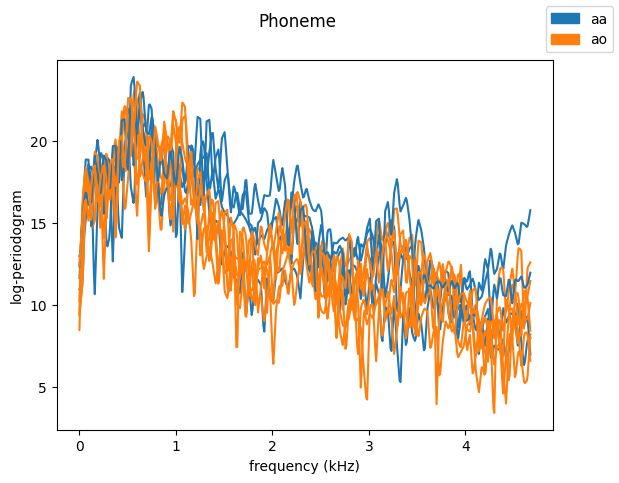

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from skfda.datasets import fetch_phoneme

X_df, y_df = fetch_phoneme(return_X_y=True, as_frame=True)
X_df = X_df[(y_df.cat.codes==0)|(y_df.cat.codes==1)]
y_df = y_df[(y_df.cat.codes==0)|(y_df.cat.codes==1)]


n_points = 150


y = y_df.cat.codes
fd = X_df.iloc[:, 0].array

new_points = fd.grid_points[0][:n_points]
new_data = fd.data_matrix[:, :n_points]

fd = fd.copy(
    grid_points=new_points,
    data_matrix=new_data,
    domain_range=(np.min(new_points), np.max(new_points)),
)

n_plot = 10
fd[:n_plot].plot(group=y_df, legend=True)
plt.show()

In [2]:
# Macros
n_basis = 20
n_neighbors = 5

test_size = 0.25
random_state = 12345
n_components = 20
optimize_params = True
n_samples_random_search = 1000
best_params = {
    "mahalanobis": 1,
    "pca_based_distance": np.ones(n_components),
    "fourier_based_distance": np.linspace(1, 5, n_basis)
    / np.sum(np.linspace(1, 5, n_basis)),
}

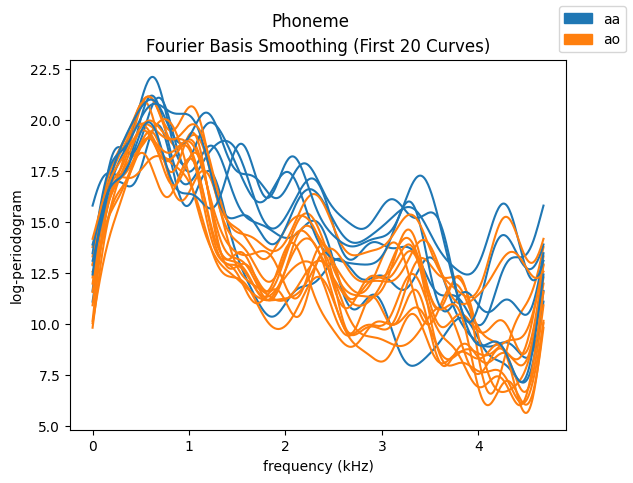

In [3]:
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import FourierBasis

fourier_basis = FourierBasis(domain_range=fd.domain_range[0], n_basis=n_basis)

smoother = BasisSmoother(basis=fourier_basis, return_basis=True)
fd_fourier = smoother.fit_transform(fd)

# Plot the smoothed functions
n_plot = 20
fd_fourier[:n_plot].plot(group=y_df[:n_plot], legend=True)
plt.title("Fourier Basis Smoothing (First 20 Curves)")
plt.show()

Component 1: 34.18% of variance (cumulative: 34.18%)
Component 2: 9.41% of variance (cumulative: 43.59%)
Component 3: 6.36% of variance (cumulative: 49.95%)
Component 4: 3.48% of variance (cumulative: 53.43%)
Component 5: 2.93% of variance (cumulative: 56.36%)
Component 6: 2.57% of variance (cumulative: 58.93%)
Component 7: 2.14% of variance (cumulative: 61.06%)
Component 8: 1.77% of variance (cumulative: 62.84%)
Component 9: 1.67% of variance (cumulative: 64.51%)
Component 10: 1.49% of variance (cumulative: 65.99%)
Component 11: 1.41% of variance (cumulative: 67.40%)
Component 12: 1.24% of variance (cumulative: 68.64%)
Component 13: 1.17% of variance (cumulative: 69.81%)
Component 14: 1.04% of variance (cumulative: 70.85%)
Component 15: 0.96% of variance (cumulative: 71.81%)
Component 16: 0.91% of variance (cumulative: 72.72%)
Component 17: 0.90% of variance (cumulative: 73.62%)
Component 18: 0.81% of variance (cumulative: 74.43%)
Component 19: 0.80% of variance (cumulative: 75.23%)
C

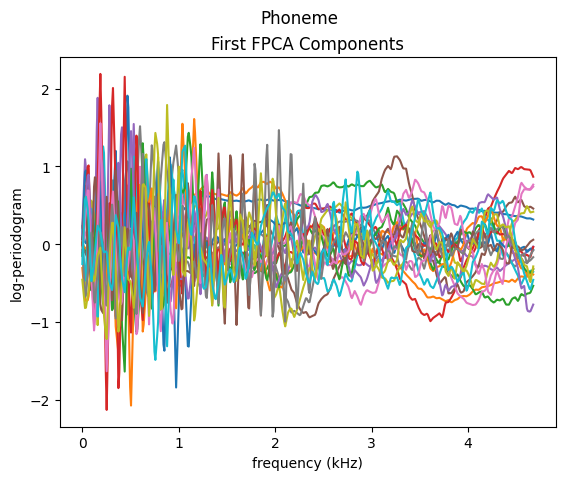

In [4]:
from skfda.preprocessing.dim_reduction import FPCA

fpca = FPCA(n_components=n_components)
fpca.fit(fd)

# Transform the data to the principal component basis
fpca.transform(fd)

# Explained variance ratio
explained_variance_ratio = fpca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Show explained variance
for i, (var, cum) in enumerate(
    zip(explained_variance_ratio, cumulative_variance, strict=False), 1,
):
    print(f"Component {i}: {var:.2%} of variance (cumulative: {cum:.2%})")

# Optional: plot the first few principal components
fpca.components_.plot(legend=True)
plt.title("First FPCA Components")
plt.show()

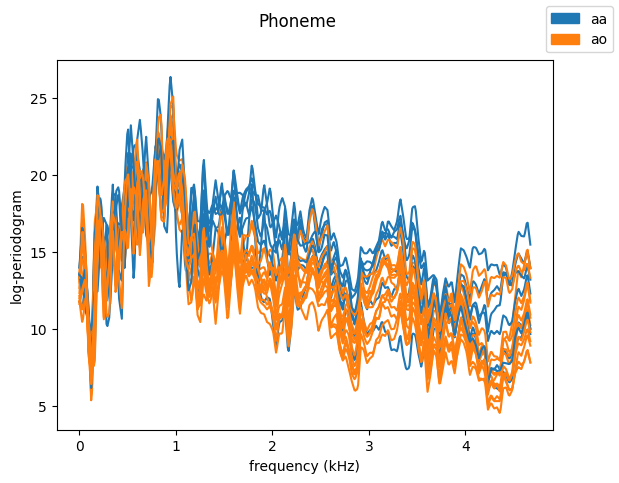

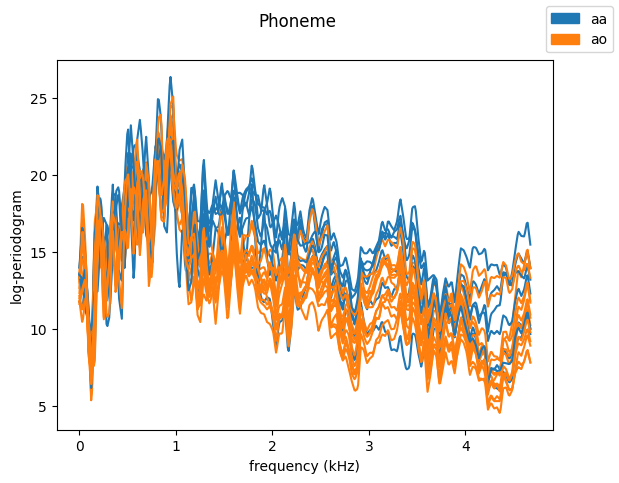

In [6]:
from skfda.representation.basis import CustomBasis

basis = CustomBasis(fdata=fpca.components_)
fd_pca = fd.to_basis(basis)
fd_pca[:n_plot].plot(group=y_df[:n_plot], legend=True)


In [111]:
from sklearn.model_selection import train_test_split

(
    fd_fourier_train,
    fd_fourier_test,
    fd_pca_train,
    fd_pca_test,
    fd_train,
    fd_test,
    y_train,
    y_test,
) = train_test_split(
    fd_fourier,
    fd_pca,
    fd,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y,
)

### Optimize Fourier Based Distance

In [112]:
from scipy.stats import norm
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV

from skfda.misc.metrics import BasisBasedDistance
from skfda.ml.classification import KNeighborsClassifier

In [113]:
classifier = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric=BasisBasedDistance(weights=np.logspace(0, 1, n_basis)),
)


def normalize(weights):
    total = np.sum(weights)
    return weights / total if total != 0 else weights


def gaussian_bump(
    center: int,
    width: int,
) -> np.ndarray:
    x = np.linspace(0, 1, n_basis)
    return norm.pdf(x, loc=center, scale=width)


rng = np.random.default_rng(42)
random_perturbations = [
    np.abs(rng.normal(loc=1, scale=0.5, size=n_basis)) for _ in range(2)
]

param_grid = {
    "metric__weights": [
        np.ones(n_basis),  # Uniform
        np.linspace(10, 1, n_basis),  # Low
        np.linspace(1, 5, n_basis),  # High
        np.concatenate(
            [
                np.linspace(1, 5, n_basis // 2),
                np.linspace(5, 1, n_basis - n_basis // 2),
            ],
        ),  # Mid
        np.logspace(0, 2, n_basis)[::-1],  # Strong low emphasis
        np.logspace(0, 1, n_basis),  # Mild high emphasis
        gaussian_bump(0.2, 0.1),
        gaussian_bump(0.5, 0.1),
        gaussian_bump(0.8, 0.1),
        np.array(
            [
                1 if n_basis // 3 <= i < n_basis // 3 + n_basis // 5 else 0.1
                for i in range(n_basis)
            ],
        ),  # Mid band
        np.array(
            [5 if i < n_basis // 3 else 1 for i in range(n_basis)],
        ),  # Emphasis on first 3
        np.array(
            [1 + np.sin(i * np.pi / 12) ** 2 for i in range(n_basis)],
        ),  # Wavy
        *random_perturbations,
        np.array(
            [1 if i < n_basis // 2 else 0 for i in range(n_basis)],
        ),  # First half on
        np.array(
            [0 if i < n_basis // 2 else 1 for i in range(n_basis)],
        ),  # Second half on
        np.array(
            [
                1 if n_basis // 3 <= i < 2 * n_basis // 3 else 0
                for i in range(n_basis)
            ],
        ),  # Middle block
    ],
}

normalized_param_grid = {
    "metric__weights": [
        normalize(weights) for weights in param_grid["metric__weights"]
    ],
}

grid = GridSearchCV(
    classifier,
    param_grid=normalized_param_grid,
    cv=5,
    scoring=make_scorer(accuracy_score),
    verbose=1,
)

# The grid search is too slow for a example. Uncomment it if you want, but it
# will take a while.
if optimize_params:
    grid.fit(fd_fourier_train, y_train)

    print("Best weights:", grid.best_params_["metric__weights"])
    print("Best CV accuracy:", grid.best_score_)

    y_pred = grid.best_estimator_.predict(fd_fourier_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {accuracy:.2%}")

    best_params["fourier_based_distance"] = grid.best_params_[
        "metric__weights"
    ]

Fitting 5 folds for each of 17 candidates, totalling 85 fits
Best weights: [0.09090909 0.08660287 0.08229665 0.07799043 0.07368421 0.06937799
 0.06507177 0.06076555 0.05645933 0.05215311 0.04784689 0.04354067
 0.03923445 0.03492823 0.03062201 0.02631579 0.02200957 0.01770335
 0.01339713 0.00909091]
Best CV accuracy: 0.8003257623744456
Test accuracy: 76.74%


### Optimize Mahalanobis Distance

In [114]:
from skfda.misc.metrics import MahalanobisDistance

classifier = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric=MahalanobisDistance(
        alpha=0.001,
    ),
)

grid = GridSearchCV(
    classifier,
    param_grid={
        "metric__alpha": [1, 1e-1, 1e-2, 1e-3, 1e-4],
    },
)

if optimize_params:
    grid.fit(fd_fourier_train, y_train)

    print("Best alpha:", grid.best_params_["metric__alpha"])
    print("Best CV accuracy:", grid.best_score_)

    y_pred = grid.best_estimator_.predict(fd_fourier_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {accuracy:.2%}")

    best_params["mahalanobis"] = grid.best_params_["metric__alpha"]

Best alpha: 1
Best CV accuracy: 0.784806804814044
Test accuracy: 77.21%


### Optimize PCA Based Distance

In [115]:
from sklearn.model_selection import RandomizedSearchCV

knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric=BasisBasedDistance(weights=np.ones(n_components)),
)

param_distributions = {
    "metric__weights": [
        np.random.dirichlet(np.ones(10))  # uniform over the probability simplex
        for _ in range(n_samples_random_search)  # generate random initial weight vectors
    ],
}

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_distributions,
    n_iter=n_samples_random_search,  # number of random samples you want to test
    cv=3,
    scoring=make_scorer(accuracy_score),
    verbose=1,
    random_state=42,
)

if optimize_params:
    random_search.fit(fd_pca_train, y_train)

    print("Best weights:", random_search.best_params_["metric__weights"])
    print("Best CV accuracy:", random_search.best_score_)

    y_pred = random_search.best_estimator_.predict(fd_pca_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {accuracy:.2%}")

    best_params["pca_based_distance"] = grid.best_params_["metric__weights"]

Fitting 3 folds for each of 1000 candidates, totalling 3000 fits


KeyboardInterrupt: 

### Results

In [ ]:
classifier = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric=BasisBasedDistance(weights=best_params["fourier_based_distance"]),
)
classifier.fit(fd_fourier_train, y_train)

y_pred = classifier.predict(fd_fourier_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

In [ ]:
from skfda.misc.metrics import l2_distance

classifier = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric=l2_distance,
)

classifier.fit(fd_train, y_train)
y_pred = classifier.predict(fd_test)
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
print(accuracy)

In [ ]:

""" results = pd.DataFrame(
    {
        "weights_index": range(len(grid.cv_results_["param_metric__weights"])),
        "mean_accuracy": grid.cv_results_["mean_test_score"],
    },
)

# Sort by best accuracy
results = results.sort_values(by="mean_accuracy", ascending=False).reset_index(
    drop=True,
)

print(results) """

In [ ]:
results = {
    "mahalanobis": [],
    "pca_based_distance": [],
    "fourier_based_distance": [],
}


def results_with_seed(seed: int) -> None:
    X_df, y_df = fetch_phoneme(return_X_y=True, as_frame=True)
    y = y_df.cat.codes
    fd = X_df.iloc[:, 0].array

    fourier_basis = FourierBasis(domain_range=fd.domain_range[0], n_basis=n_basis)

    smoother = BasisSmoother(basis=fourier_basis, return_basis=True)
    fd_fourier = smoother.fit_transform(fd)

    basis = FPCABasis(X=fd, n_basis=n_components)
    fd_pca = fd.to_basis(basis)

    (
        fd_fourier_train,
        fd_fourier_test,
        fd_pca_train,
        fd_pca_test,
        fd_train,
        fd_test,
        y_train,
        y_test,
    ) = train_test_split(
        fd_fourier,
        fd_pca,
        fd,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    classifier_fourier = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=BasisBasedDistance(
            weights=best_params["fourier_based_distance"],
        ),
    )

    classifier_mahalanobis = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=MahalanobisDistance(
            alpha=best_params["mahalanobis"],
        ),
    )

    classifier_pca = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=BasisBasedDistance(
            weights=best_params["pca_based_distance"],
        ),
    )


    classifier_fourier.fit(fd_fourier_train, y_train)
    y_pred = classifier_fourier.predict(fd_fourier_test)
    results["fourier_based_distance"].append(accuracy_score(y_test, y_pred))

    classifier_mahalanobis.fit(fd_fourier_train, y_train)
    y_pred = classifier_mahalanobis.predict(fd_fourier_test)
    results["mahalanobis"].append(accuracy_score(y_test, y_pred))

    classifier_pca.fit(fd_pca_train, y_train)
    y_pred = classifier_pca.predict(fd_pca_test)
    results["pca_based_distance"].append(accuracy_score(y_test, y_pred))


In [ ]:
for i in range(10):
    results_with_seed(i)

# Summarize
for key in results:
    accs = np.array(results[key])
    print(f"{key}: {accs.mean():.3f} ± {accs.std():.3f}")